<!-- Notebook acadêmico — resolução de laboratório de Deep Learning. -->
<!-- Documentação: ../DOCUMENTACAO.md -->
> **Portfólio acadêmico:** saídas da última execução preservadas. Consulte o README para reprodução.


# Disciplina: Deep Learning
## Lab 03 - Redes Neurais Multicamadas (MLP) e Arquiteturas Feedforward

**Orientações:**
1. Leia atentamente o enunciado de cada questão.
2. O gabarito está implementado logo abaixo de cada enunciado.
3. Certifique-se de executar as células de importação antes de iniciar os exercícios.
4. Explore os hiperparâmetros (taxa de aprendizagem, número de neurônios) para observar as mudanças no aprendizado.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Configuração de dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Utilizando: {device}')

Utilizando: cuda


### 🔹 Questão 1: Preparação de Dados (Problema Não-Linear)
**Enunciado:** Para treinar uma MLP, precisamos de dados que não sejam linearmente separáveis. Utilize o `sklearn` para gerar o dataset 'Moons', normalize os dados e converta-os para Tensores do PyTorch.

**Requisitos:**
- Gerar 1000 amostras com ruído (noise) de 0.2.
- Dividir em treino (80%) e teste (20%).
- Normalizar os dados (StandardScaler).
- Converter para `torch.FloatTensor`.

In [2]:
# Gerando os dados
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Conversão para tensores PyTorch
X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).view(-1, 1).to(device)
y_test = torch.FloatTensor(y_test).view(-1, 1).to(device)

print(f"Dataset preparado! Formato de X_train: {X_train.shape}")

Dataset preparado! Formato de X_train: torch.Size([800, 2])


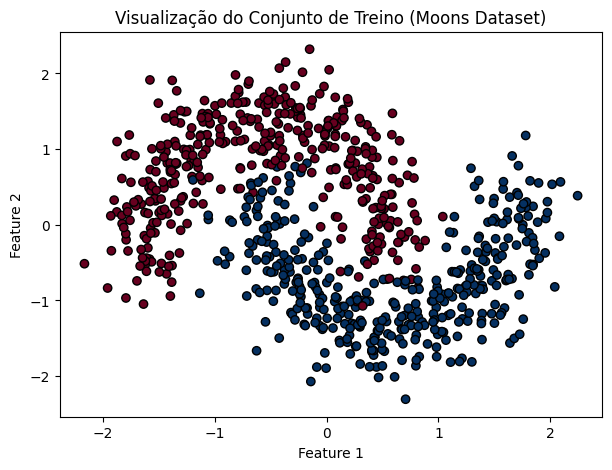

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train.cpu().numpy()[:, 0], X_train.cpu().numpy()[:, 1], c=y_train.cpu().numpy().flatten(), cmap=plt.cm.RdBu, edgecolors='k')
plt.title("Visualização do Conjunto de Treino (Moons Dataset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 🔹 Questão 2: Definição da Arquitetura MLP
**Enunciado:** Crie uma classe de modelo no PyTorch que represente uma MLP Feedforward para classificação binária.

**Requisitos:**
- Camada de entrada (conforme número de features).
- Pelo menos duas camadas ocultas com ativação ReLU.
- Camada de saída com ativação Sigmoid.

In [46]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # Camadas densas (Lineares)
        self.layer1 = nn.Linear(input_dim, 8) # Entrada -> Oculta 1
        self.layer2 = nn.Linear(8, 4)         # Oculta 1 -> Oculta 2
        self.output = nn.Linear(4, 1)          # Oculta 2 -> Saída

        # Funções de ativação
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x)) # Ativação na primeira camada
        x = self.relu(self.layer2(x)) # Ativação na segunda camada
        x = self.sigmoid(self.output(x)) # Saída probabilística
        return x

# Instanciando o modelo
model = MLP(input_dim=2).to(device)
print(model)

MLP(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


### 🔹 Questão 3: Treinamento do Modelo
**Enunciado:** Implemente o loop de treinamento para a rede criada. Você deve definir a função de perda (Loss) e o otimizador.

**Requisitos:**
- Loss: Binary Cross Entropy.
- Otimizador: Adam ou SGD.
- Treinar por 100 épocas e imprimir a perda a cada 10.

In [47]:
# Initialize a dictionary to store parameter norms over epochs
parameter_evolution_data = {name: [] for name, param in model.named_parameters()}

criterion = nn.BCELoss() # Perda para classificação binária
optimizer = optim.Adam(model.parameters(), lr=0.01) # Otimizador Adam

epochs = 1000
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass e otimização
    optimizer.zero_grad() # Zera gradientes anteriores
    loss.backward()        # Calcula novos gradientes
    optimizer.step()       # Atualiza pesos

    # Store the L2 norm of each parameter after update
    for name, param in model.named_parameters():
        parameter_evolution_data[name].append(param.data.norm().item())

    if (epoch + 1) % 10 == 0:
        print(f'Época [{epoch+1}/{epochs}], Perda: {loss.item():.4f}')

    if loss.item()<=0.1:
      break

Época [10/1000], Perda: 0.6175
Época [20/1000], Perda: 0.5102
Época [30/1000], Perda: 0.4095
Época [40/1000], Perda: 0.3369
Época [50/1000], Perda: 0.3044
Época [60/1000], Perda: 0.2928
Época [70/1000], Perda: 0.2784
Época [80/1000], Perda: 0.2631
Época [90/1000], Perda: 0.2501
Época [100/1000], Perda: 0.2339
Época [110/1000], Perda: 0.2144
Época [120/1000], Perda: 0.1912
Época [130/1000], Perda: 0.1644
Época [140/1000], Perda: 0.1376
Época [150/1000], Perda: 0.1159
Época [160/1000], Perda: 0.1025


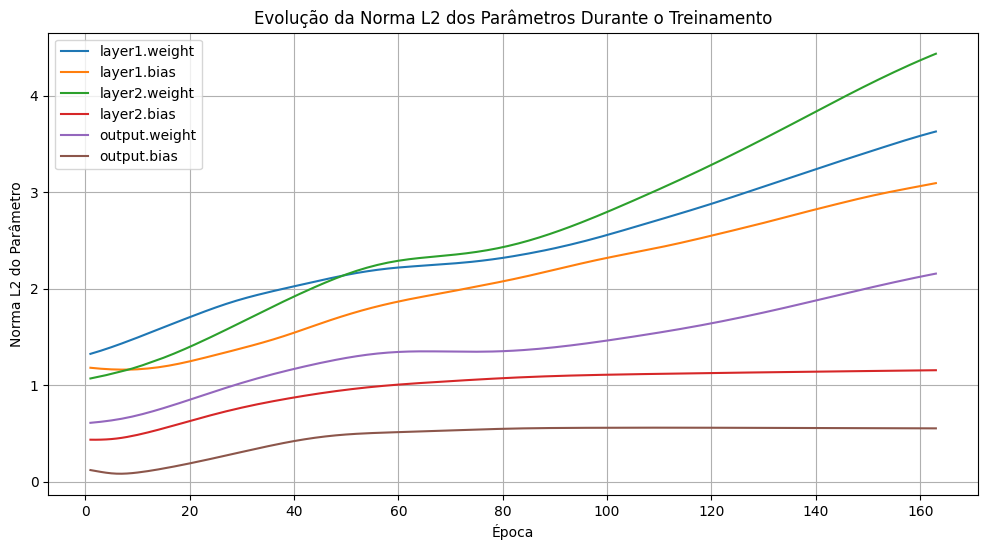

In [51]:
plt.figure(figsize=(12, 6))
for name, norms in parameter_evolution_data.items():
    plt.plot(range(1, len(norms) + 1), norms, label=name)

plt.title('Evolução da Norma L2 dos Parâmetros Durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Norma L2 do Parâmetro')
plt.legend()
plt.grid(True)
plt.show()

### 🔹 Questão 4: Avaliação e Visualização
**Enunciado:** Avalie o desempenho do modelo no conjunto de teste e plote a fronteira de decisão.

**Requisitos:**
- Calcular a acurácia no set de teste.
- Gerar um gráfico mostrando como a MLP separou as classes.

Acurácia no Teste: 97.50%


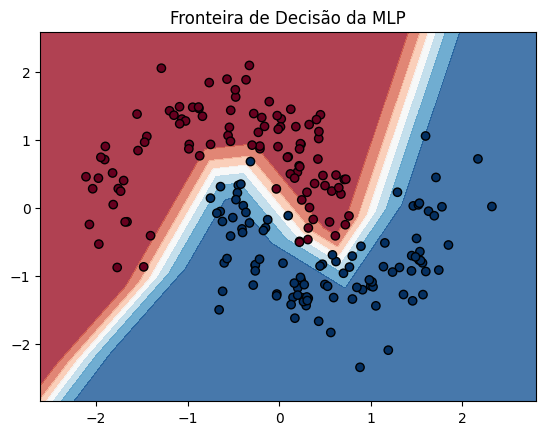

In [52]:
with torch.no_grad():
    # Predições no conjunto de teste
    y_pred = model(X_test)
    y_pred_cls = y_pred.round() # Converte probabilidades em 0 ou 1
    accuracy = (y_pred_cls.eq(y_test).sum() / float(y_test.shape[0]))
    print(f'Acurácia no Teste: {accuracy.item()*100:.2f}%')

# Função para plotar fronteira de decisão
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu)
    plt.title("Fronteira de Decisão da MLP")
    plt.show()

plot_decision_boundary(model, X_test.cpu().numpy(), y_test.cpu().numpy().flatten())